In [1]:
import pandas as pd

df = pd.read_csv('/content/countries of the world.csv')
display(df.head())

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [2]:
df.columns = df.columns.str.strip()
df['Country'] = df['Country'].str.strip()
df['Region'] = df['Region'].str.strip()

columns_to_convert = [
    'Pop. Density (per sq. mi.)',
    'Coastline (coast/area ratio)',
    'Net migration',
    'Infant mortality (per 1000 births)',
    'Literacy (%)',
    'Phones (per 1000)',
    'Arable (%)',
    'Crops (%)',
    'Other (%)',
    'Birthrate',
    'Deathrate',
    'Agriculture',
    'Industry',
    'Service',
    'Climate'
]

for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

None

In [3]:
missing_values_percentage = df.isnull().sum() / len(df) * 100

missing_values_df = pd.DataFrame({'Column': missing_values_percentage.index, 'Missing_Percentage': missing_values_percentage.values})
missing_values_df = missing_values_df[missing_values_df['Missing_Percentage'] > 0].sort_values(by='Missing_Percentage', ascending=False)

display(missing_values_df)

,Column,Missing_Percentage
14,Climate,9.691630
9,Literacy (%),7.929515
18,Industry,7.048458
17,Agriculture,6.607930
19,Service,6.607930
10,Phones (per 1000),1.762115
16,Deathrate,1.762115
15,Birthrate,1.321586
6,Net migration,1.321586
7,Infant mortality (per 1000 births),1.321586


In [4]:
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())

display(df.isnull().sum())

,0
Country,0
Region,0
Population,0
Area (sq. mi.),0
Pop. Density (per sq. mi.),0
Coastline (coast/area ratio),0
Net migration,0
Infant mortality (per 1000 births),0
GDP ($ per capita),0
Literacy (%),0


In [6]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

df_encoded = df.copy()

le = LabelEncoder()
df_encoded['Country_Encoded'] = le.fit_transform(df_encoded['Country'])

numerical_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['Country_Encoded']]

ct = ColumnTransformer([
    ('scale', StandardScaler(), numerical_cols),
    ('onehot', OneHotEncoder(sparse_output=False), ['Region'])
], remainder='drop')

processed_data = ct.fit_transform(df_encoded)

new_col_names = numerical_cols + ct.named_transformers_['onehot'].get_feature_names_out(['Region']).tolist()
df_final = pd.DataFrame(processed_data, columns=new_col_names)
df_final['Country_Encoded'] = df_encoded['Country_Encoded'].values

display(df_final.head())

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE,Country_Encoded
0,0.019695,0.027583,-0.199844,-0.293443,4.750696,3.636688,-0.898554,-2.481004,-1.032796,-0.128695,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.213877,-0.318797,-0.153603,-0.275974,-1.025201,-0.398754,-0.518735,0.193960,-0.731200,0.562986,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.035618,0.998421,-0.220490,-0.292889,-0.088346,-0.128489,-0.368806,-0.680038,-0.700597,-0.816517,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
3,-0.243834,-0.334779,-0.053514,0.514709,-4.281495,-0.747988,-0.168902,0.750140,0.103956,-0.293124,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3
4,-0.243720,-0.334629,-0.137002,-0.293443,1.354081,-0.896805,0.930574,0.909049,1.158212,-0.893713,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4


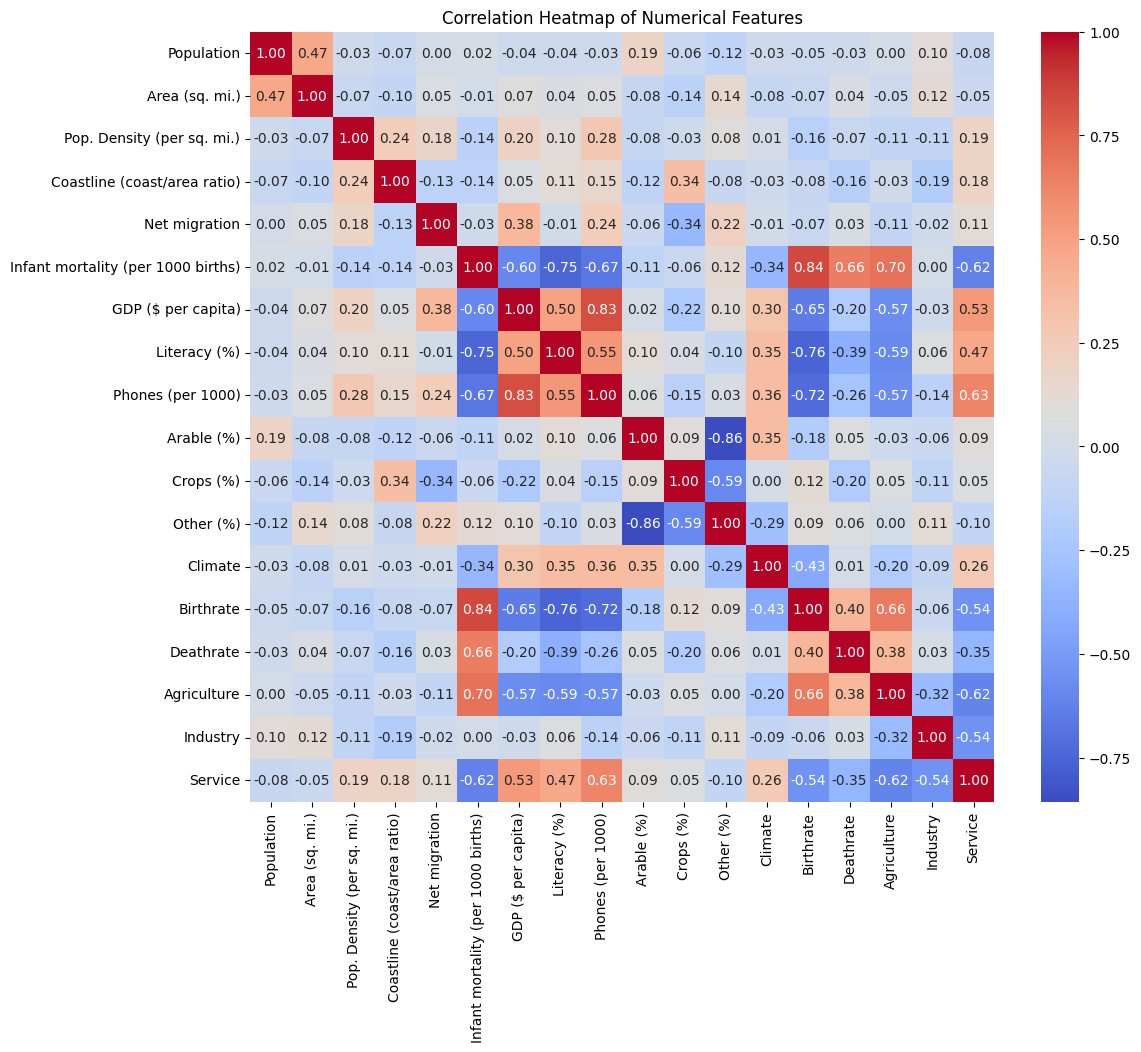

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

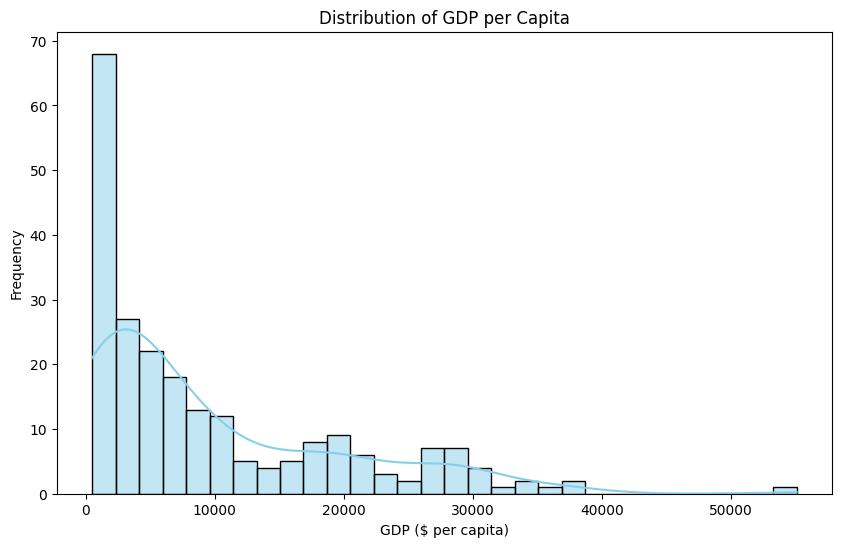

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['GDP ($ per capita)'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP ($ per capita)')
plt.ylabel('Frequency')
plt.show()

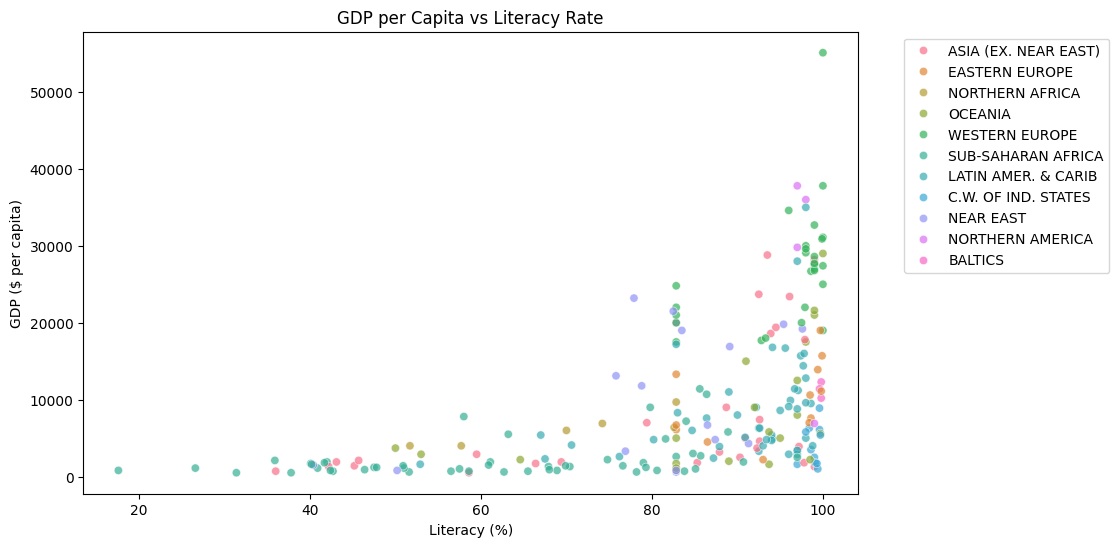

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Literacy (%)', y='GDP ($ per capita)', hue='Region', alpha=0.7)
plt.title('GDP per Capita vs Literacy Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

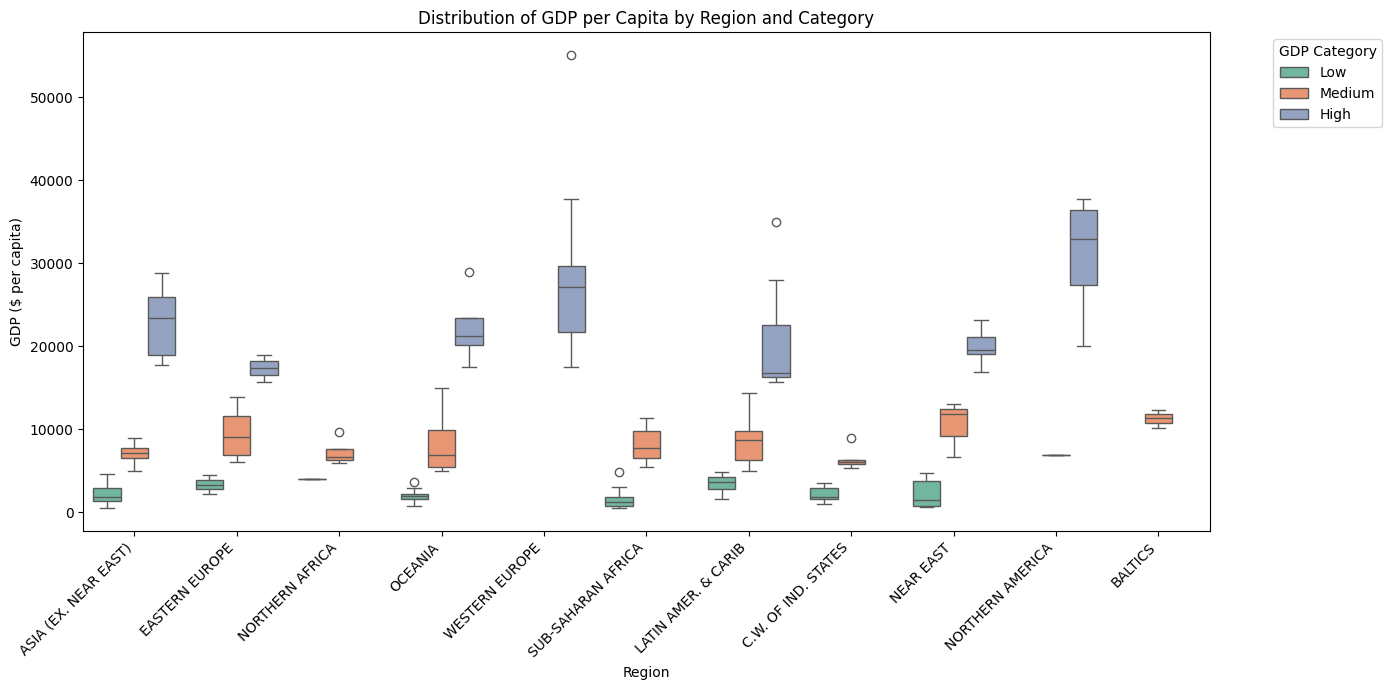

In [12]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Region', y='GDP ($ per capita)', hue='GDP_Category', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of GDP per Capita by Region and Category')
plt.legend(title='GDP Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

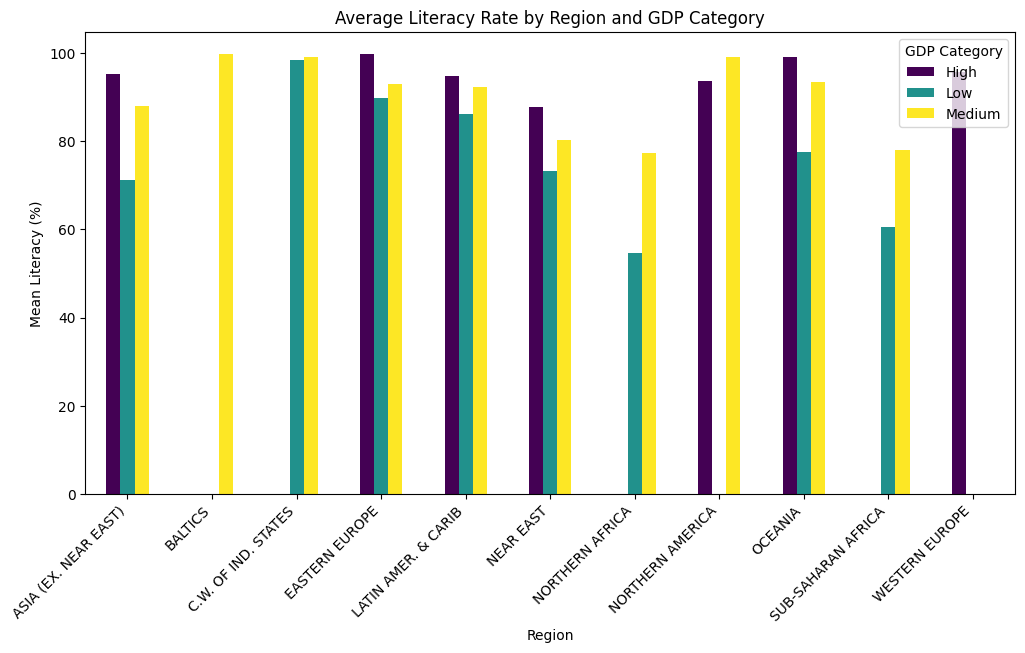

In [13]:
plt.figure(figsize=(12, 6))
# Comparing mean literacy across GDP categories within regions
region_cat_literacy = df.groupby(['Region', 'GDP_Category'])['Literacy (%)'].mean().unstack()
region_cat_literacy.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Literacy Rate by Region and GDP Category')
plt.ylabel('Mean Literacy (%)')
plt.legend(title='GDP Category')
plt.show()

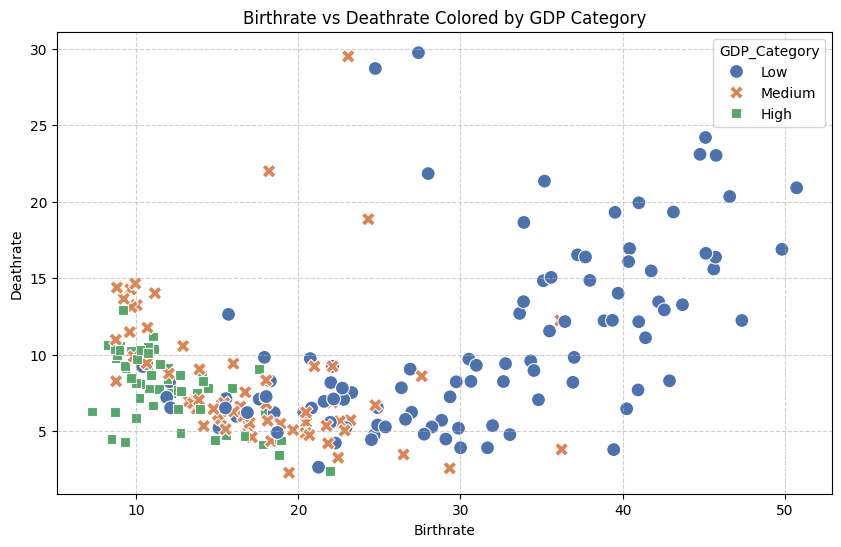

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Birthrate', y='Deathrate', hue='GDP_Category', style='GDP_Category', s=100, palette='deep')
plt.title('Birthrate vs Deathrate Colored by GDP Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [10]:
def classify_gdp(row):
    gdp = row['GDP ($ per capita)']
    if gdp < 5000:
        return 'Low'
    elif gdp <= 15000:
        return 'Medium'
    else:
        return 'High'

df['GDP_Category'] = df.apply(classify_gdp, axis=1)

display(df[['Country', 'GDP ($ per capita)', 'GDP_Category']].head(10))
print("\nCategory Counts:")
print(df['GDP_Category'].value_counts())

,Country,GDP ($ per capita),GDP_Category
0,Afghanistan,700.0,Low
1,Albania,4500.0,Low
2,Algeria,6000.0,Medium
3,American Samoa,8000.0,Medium
4,Andorra,19000.0,High
5,Angola,1900.0,Low
6,Anguilla,8600.0,Medium
7,Antigua & Barbuda,11000.0,Medium
8,Argentina,11200.0,Medium
9,Armenia,3500.0,Low



Category Counts:
GDP_Category
Low       104
Medium     65
High       58
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder

le_gdp = LabelEncoder()
df['GDP_Category_Encoded'] = le_gdp.fit_transform(df['GDP_Category'])

display(df[['Country', 'GDP_Category', 'GDP_Category_Encoded']].head(10))
print(f"\nClasses: {list(le_gdp.classes_)}")

,Country,GDP_Category,GDP_Category_Encoded
0,Afghanistan,Low,1
1,Albania,Low,1
2,Algeria,Medium,2
3,American Samoa,Medium,2
4,Andorra,High,0
5,Angola,Low,1
6,Anguilla,Medium,2
7,Antigua & Barbuda,Medium,2
8,Argentina,Medium,2
9,Armenia,Low,1



Classes: ['High', 'Low', 'Medium']


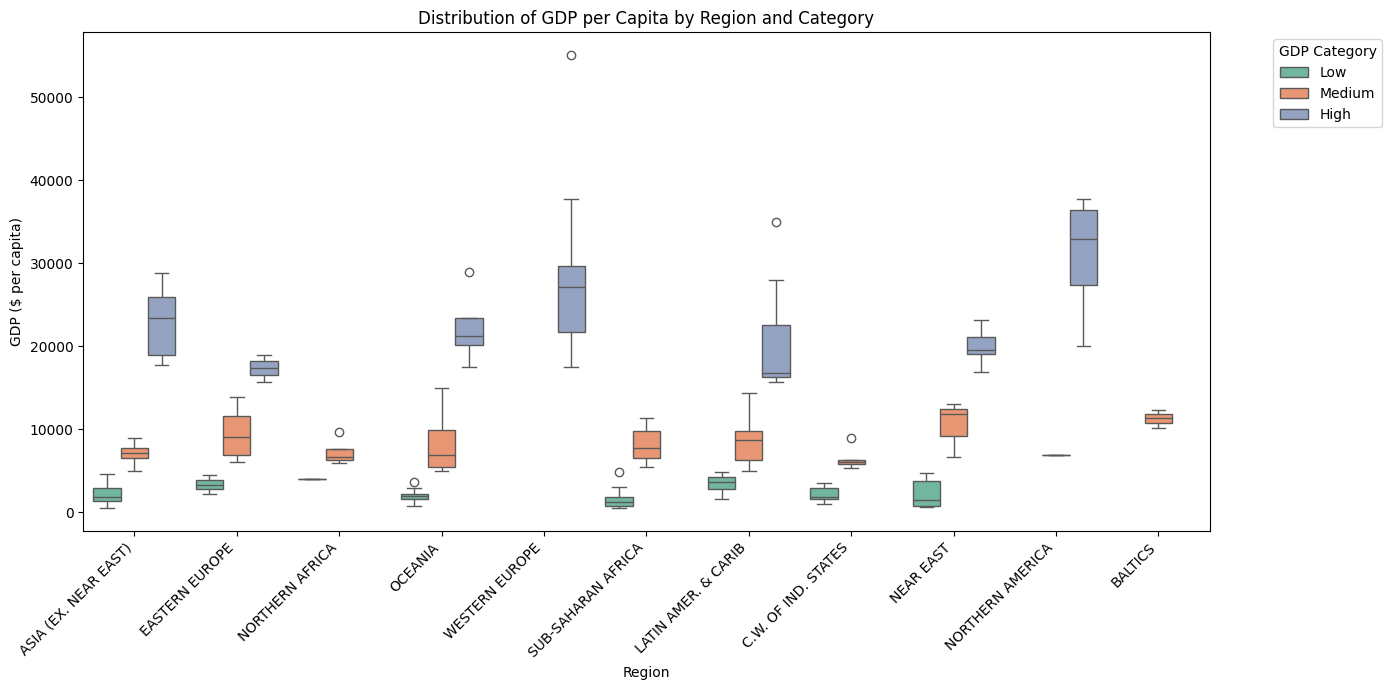

In [15]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Region', y='GDP ($ per capita)', hue='GDP_Category', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of GDP per Capita by Region and Category')
plt.legend(title='GDP Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

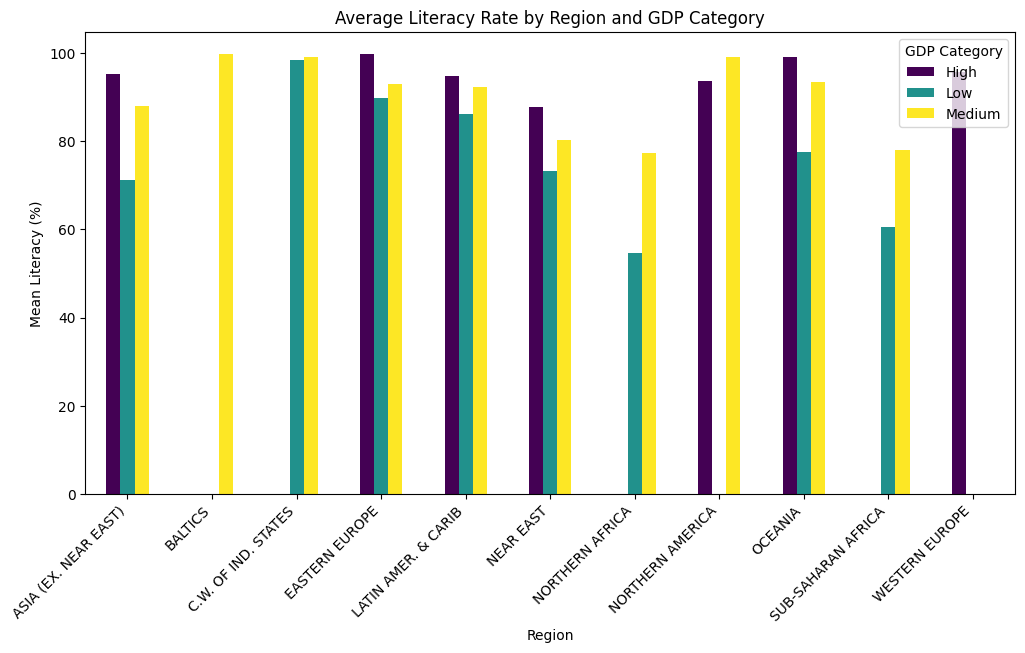

In [16]:
plt.figure(figsize=(12, 6))
# Comparing mean literacy across GDP categories within regions
region_cat_literacy = df.groupby(['Region', 'GDP_Category'])['Literacy (%)'].mean().unstack()
region_cat_literacy.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Literacy Rate by Region and GDP Category')
plt.ylabel('Mean Literacy (%)')
plt.legend(title='GDP Category')
plt.show()

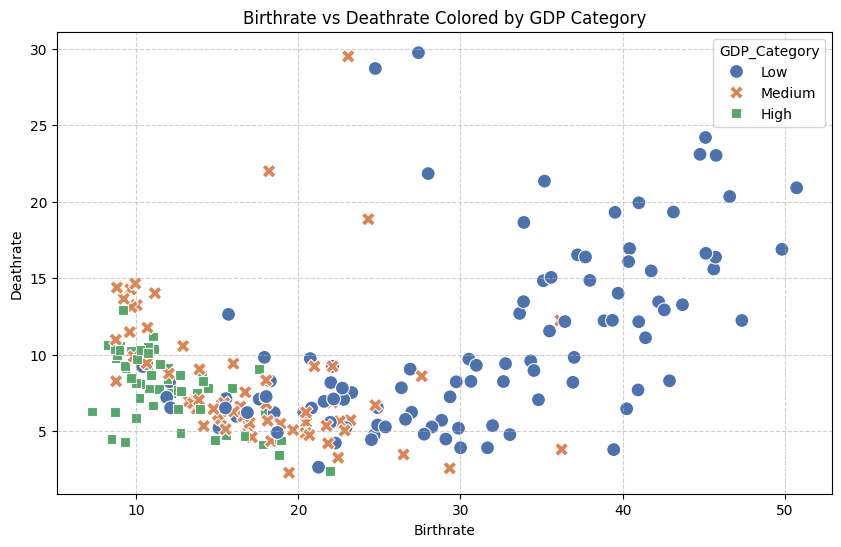

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Birthrate', y='Deathrate', hue='GDP_Category', style='GDP_Category', s=100, palette='deep')
plt.title('Birthrate vs Deathrate Colored by GDP Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_final.drop(columns=['Country_Encoded'])
y = df['GDP_Category_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
model = LogisticRegression(max_iter=1000, multi_class='multinomial')
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [20]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print(classification_report(y_test, y_pred, target_names=le_gdp.classes_))

Accuracy: 0.83
              precision    recall  f1-score   support

        High       0.85      0.92      0.88        12
         Low       0.94      0.81      0.87        21
      Medium       0.67      0.77      0.71        13

    accuracy                           0.83        46
   macro avg       0.82      0.83      0.82        46
weighted avg       0.84      0.83      0.83        46

